In [20]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Balaji\AppData\Roaming\Python\Python312\Scripts\diamonds.csv")
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


Column Details:

carat - Weight of the diamond (in carats). A primary factor influencing price.
cut - Quality of the diamond's cut. Ordinal categories: Fair, Good, Very Good, Premium, Ideal.
color - Diamond color grading from best (D) to worst (J). Ordinal categories: D, E, F, G, H, I, J.
clarity - Measure of diamond inclusions (internal flaws) and blemishes. Categories: IF (Internally Flawless), VVS1, VVS2, VS1, VS2, SI1, SI2, I1.
depth - Total depth percentage = (z / mean(x, y)) × 100. Affects brilliance and appearance.
table - Width of the diamond’s top facet as a percentage of the average diameter. Impacts how light reflects internally.
price - Price of the diamond in USD. Target variable(Convert to INR)
x - Length of the diamond (in mm).
y - Width of the diamond (in mm).
z - Depth (height) of the diamond (in mm).



In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [22]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [23]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [24]:
# Null Values Check:
df.isnull().sum() # No Null Values

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [25]:
# Duplicates check:
df.duplicated().sum()

146

In [26]:
# Dropping Duplicates:
df.drop_duplicates(inplace=True)

In [27]:
df.duplicated().sum()

0

In [28]:
# Zero Values Check:
(df["x"]==0).sum()

7

In [29]:
(df["y"]==0).sum()

6

In [30]:
(df["z"]==0).sum()

19

Inference:

Checking zero values for x,y,z because of length,width and height of Diamond
Out of 54940 records 44 records were in having 0's

In [31]:
# Removing Zeros:
df = df[(df["x"] > 0) & (df["y"] > 0) &(df["z"] > 0)]

In [32]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


Feature Selection Methods Inference:

Correlation: Use panna mudiyum.
Aana:cut,color,clarity - Categorical.Full picture kidaikadhu.

VIF - Use panna mudiyum.
Aana:Prupose - Multicollinearity - check panna mattum,Feature importance solladhu.

RFE - Use panna mudiyum but 9 features ku konjam overkill

Conclusion:
I evaluated the available feature selection options. Since the dataset contained a small number of features and the relationship between diamond attributes and price may not be purely linear, I selected Random Forest Feature Importance. It provides a direct ranking of predictors and captures non-linear interactions better than correlation-based methods

In [35]:
# Skewness Check:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
df[num_cols].skew().sort_values(ascending=False)


y        2.470200
price    1.618220
z        1.589309
carat    1.113218
table    0.792069
x        0.396908
depth   -0.113711
dtype: float64

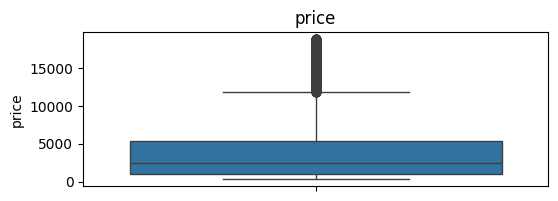

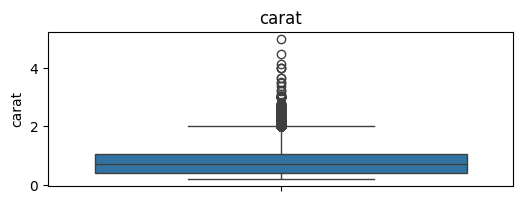

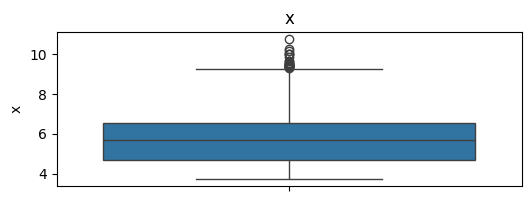

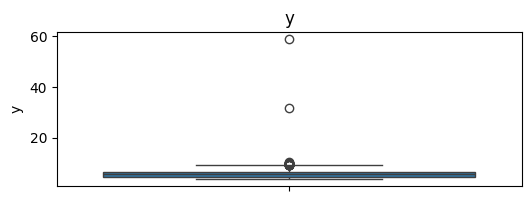

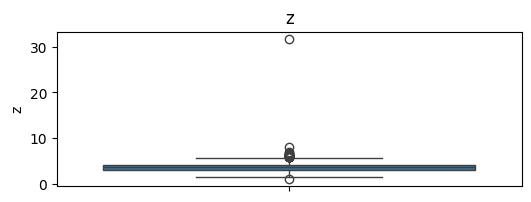

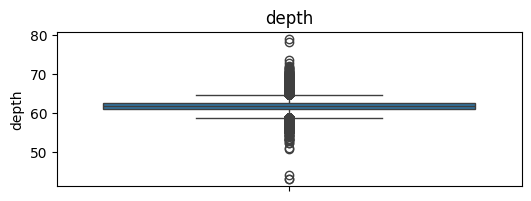

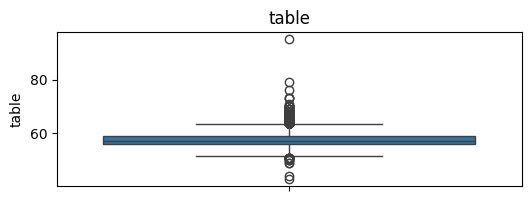

In [36]:
# Outlier Detection:
import seaborn as sns
import matplotlib.pyplot as plt
cols = ["price","carat","x","y","z","depth","table"]
for col in cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(data=df[col])
    plt.title(col)
    plt.show()
    

In [37]:
#Capping Technique:
cols = ["price","carat","x","y","z","depth","table"]
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = df[col].clip(lower=lower,
                        upper=upper)
    

C:\Users\Balaji\AppData\Local\Temp\ipykernel_23032\4133815382.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower=lower,
C:\Users\Balaji\AppData\Local\Temp\ipykernel_23032\4133815382.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower=lower,
C:\Users\Balaji\AppData\Local\Temp\ipykernel_23032\4133815382.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

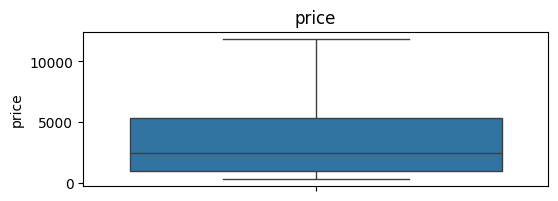

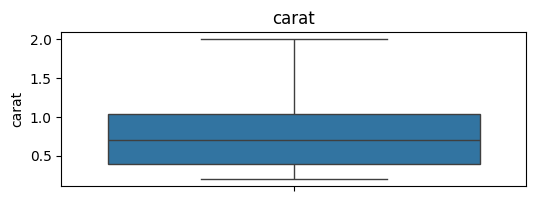

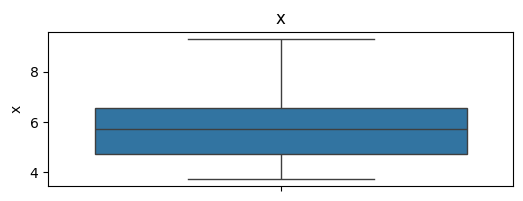

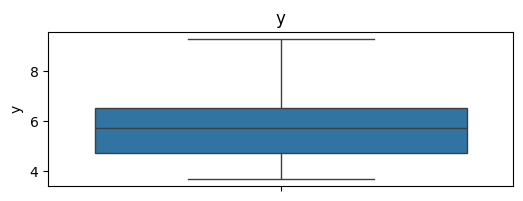

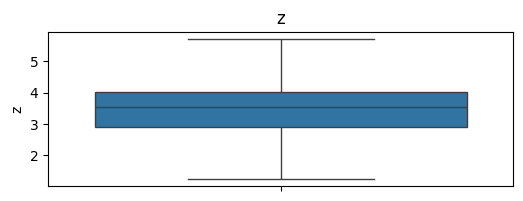

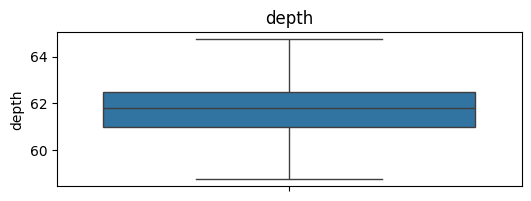

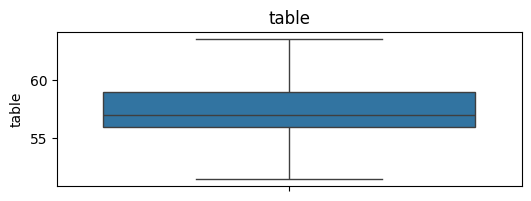

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
cols = ["price","carat","x","y","z","depth","table"]
for col in cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(data=df[col])
    plt.title(col)
    plt.show()

In [39]:
# Skewness Check:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
df[num_cols].skew().sort_values(ascending=False)

price    1.148277
carat    0.899432
table    0.472940
x        0.392541
y        0.388342
z        0.384648
depth   -0.228335
dtype: float64